# Modelado y Simulación de la Demanda de Energía Eléctrica en la Región Centro (Marzo 2025)

### Descripción breve del trabajo

En este trabajo se analizan datos reales de demanda eléctrica (MW) y temperatura para la Región Centro del SADI (principalmente Córdoba y San Luis), registrados cada 15 minutos durante marzo de 2025. El objetivo es aplicar conceptos de modelado y simulación para estudiar el comportamiento de la demanda en horario diurno, diferenciar días hábiles y no hábiles y evaluar cómo podría cambiar la demanda promedio diaria ante un escenario hipotético de aumento de temperatura de +2 °C.

## 0. Importación de librerías

In [28]:
# Librerías estándar
from datetime import datetime, timedelta

# Manejo de datos y requests
import requests
import pandas as pd
import numpy as np
from tqdm import tqdm

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística y distribuciones
import scipy.stats as st
from scipy.stats import (
    shapiro,      # Test de normalidad Shapiro-Wilk
    kstest,       # Kolmogorov-Smirnov
    norm,         # Distribución Normal
    lognorm       # Distribución Lognormal
)

## 1. Obtención de los datos

En esta sección se descargan los datos de **demanda eléctrica (MW)** y **temperatura (°C)** para la **Región Centro** durante **marzo de 2025**, utilizando la API pública de CAMMESA. La frecuencia de los datos es de 15 minutos (96 registros por día).

Antes de iniciar la descarga completa, se realiza una **verificación del estado del servicio (ping)** para confirmar que la API responde correctamente.

In [29]:
# === 1.1 Verificación del estado de la API (ping) ===

# Endpoint base de la API CAMMESA
BASE_URL = "https://api.cammesa.com/demanda-svc/demanda/ObtieneDemandaYTemperaturaRegionByFecha"

# Elegimos una fecha de prueba
params_test = {
    "fecha": "2025-10-29",
    "id_region": 1002  # Total SADI
}

try:
    r = requests.get(BASE_URL, params=params_test, timeout=10)
    if r.status_code == 200:
        print("Conexión exitosa con la API CAMMESA.")
    else:
        print(f"La API respondió con código {r.status_code}.")
except Exception as e:
    print("Error al intentar conectar con la API:")
    print(e)

Conexión exitosa con la API CAMMESA.


### 1.2 Obtención de ID de regiones

La API de CAMMESA dispone de un endpoint que lista todas las regiones eléctricas disponibles.  
Esto permite identificar el código correspondiente a la **Región Centro**, la cual es nuestra región de interés.

In [30]:
# === 1.2 Obtención de ID de regiones ===

url_regiones = "https://api.cammesa.com/demanda-svc/demanda/RegionesDemanda"

r = requests.get(url_regiones, timeout=20)
r.raise_for_status()
regiones = r.json()

df_regiones = pd.DataFrame(regiones)
df_regiones[['id', 'nombre']]

,id,nombre
0,418,NEA
1,419,NOA
2,426,GBA
3,422,Centro
4,111,Patagonia
5,417,Litoral
6,420,Comahue
7,425,Provincia de Buenos Aires
8,429,Cuyo
9,1002,Total del SADI


### 1.3 Descarga completa del mes de marzo 2025

Una vez verificada la conexión y el identificador de la Región Centro (`id_region = 422`), se procede a descargar los datos de **demanda eléctrica (MW)** y **temperatura (°C)** correspondientes a todo el mes de marzo de 2025.

Los datos son solicitados día por día mediante el endpoint:
> `https://api.cammesa.com/demanda-svc/demanda/ObtieneDemandaYTemperaturaRegionByFecha`

Cada respuesta se agrega a un dataframe que consolida el mes completo.

In [31]:
# === 1.3 Descarga completa del mes de marzo 2025 ===

BASE_URL = "https://api.cammesa.com/demanda-svc/demanda/ObtieneDemandaYTemperaturaRegionByFecha"
ID_REGION = 422  # Región Centro
FECHA_INICIO = datetime(2025, 3, 1)
FECHA_FIN = datetime(2025, 3, 31)

# Generamos todas las fechas del mes
fechas = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN, freq="D")

# Lista para almacenar resultados
registros = []

print("Descargando datos diarios desde la API de CAMMESA...\n")
for fecha in tqdm(fechas, desc="Progreso", ncols=90):
    params = {"fecha": fecha.strftime("%Y-%m-%d"), "id_region": ID_REGION}
    r = requests.get(BASE_URL, params=params, timeout=20)
    r.raise_for_status()
    registros += r.json()

# Convertir a dataframe
df = pd.DataFrame(registros)

print(f"\nDescarga completa. Registros totales: {len(df):,}")

# Guardamos CSV
nombre_inicio = FECHA_INICIO.strftime("%Y-%m-%d")
nombre_fin    = FECHA_FIN.strftime("%Y-%m-%d")

csv_path = f"cammesa_demanda_temp_{ID_REGION}_{nombre_inicio}_a_{nombre_fin}.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")

print(f"\nCSV guardado como: {csv_path}")

Descargando datos diarios desde la API de CAMMESA...



Progreso: 100%|███████████████████████████████████████████| 31/31 [00:27<00:00,  1.11it/s]


Descarga completa. Registros totales: 8,958

CSV guardado como: cammesa_demanda_temp_422_2025-03-01_a_2025-03-31.csv


## 2. Limpieza y preparación de los datos

En esta sección se realiza la limpieza inicial del dataset obtenido desde la API de CAMMESA.  
Las tareas principales son:

- Conversión de la columna `fecha` a tipo datetime.  
- Separación de hora del día (útil para distinguir períodos diurnos y nocturnos).  
- Renombrado de columnas para mayor claridad (`dem` a `demanda`, `temp` a `temperatura`).  
- Revisión de valores nulos y duplicados.  
- Verificación del rango temporal y estructura general de los datos.

In [32]:
# Visualización de primeros 5 registros
df.head()

,fecha,dem,temp
0,2025-03-01T00:05:00.000-0300,1591,NaN
1,2025-03-01T00:10:00.000-0300,1581,NaN
2,2025-03-01T00:15:00.000-0300,1572,21.5
3,2025-03-01T00:20:00.000-0300,1564,NaN
4,2025-03-01T00:25:00.000-0300,1551,NaN


In [33]:
# Datatypes de las columnas
df.dtypes

,0
fecha,object
dem,int64
temp,float64


In [34]:
# Renombrar columnas para mayor claridad
df = df.rename(columns={
    "fecha": "datetime",
    "dem": "demanda",
    "temp": "temperatura"
})

In [35]:
# Conversión de fecha a tipo datetime
df["datetime"] = pd.to_datetime(df["datetime"])

In [36]:
# Extraer datos de columna datetime
# Crear columna fecha yyyy-mm-dd
df["fecha"] = df["datetime"].dt.date
# Crear columna hora hh:mm
df["hora"]  = df["datetime"].dt.strftime("%H:%M")
# Crear columna día (número)
df["dia"]  = df["datetime"].dt.day
# Crear columna día de la semana (nombre)
df["dia_semana"]  = df["datetime"].dt.day_name()

In [37]:
df.head()

,datetime,demanda,temperatura,fecha,hora,dia,dia_semana
0,2025-03-01 00:05:00-03:00,1591,NaN,2025-03-01,00:05,1,Saturday
1,2025-03-01 00:10:00-03:00,1581,NaN,2025-03-01,00:10,1,Saturday
2,2025-03-01 00:15:00-03:00,1572,21.5,2025-03-01,00:15,1,Saturday
3,2025-03-01 00:20:00-03:00,1564,NaN,2025-03-01,00:20,1,Saturday
4,2025-03-01 00:25:00-03:00,1551,NaN,2025-03-01,00:25,1,Saturday


In [38]:
dias = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

df["dia_semana"] = df["datetime"].dt.day_name().map(dias)

In [39]:
df.head()

,datetime,demanda,temperatura,fecha,hora,dia,dia_semana
0,2025-03-01 00:05:00-03:00,1591,NaN,2025-03-01,00:05,1,Sábado
1,2025-03-01 00:10:00-03:00,1581,NaN,2025-03-01,00:10,1,Sábado
2,2025-03-01 00:15:00-03:00,1572,21.5,2025-03-01,00:15,1,Sábado
3,2025-03-01 00:20:00-03:00,1564,NaN,2025-03-01,00:20,1,Sábado
4,2025-03-01 00:25:00-03:00,1551,NaN,2025-03-01,00:25,1,Sábado


In [40]:
# Clasificación base: lunes a viernes = hábil, sábado/domingo = no hábil
df["tipo_dia"] = np.where(df["datetime"].dt.weekday < 5, "Hábil", "No hábil")

# Feriados nacionales en marzo 2025
feriados = ["2025-03-03", "2025-03-04", "2025-03-24"]
feriados = pd.to_datetime(feriados).date

# Reetiquetar feriados como "No hábil"
df.loc[df["fecha"].isin(feriados), "tipo_dia"] = "No hábil"

In [41]:
df.head()

,datetime,demanda,temperatura,fecha,hora,dia,dia_semana,tipo_dia
0,2025-03-01 00:05:00-03:00,1591,NaN,2025-03-01,00:05,1,Sábado,No hábil
1,2025-03-01 00:10:00-03:00,1581,NaN,2025-03-01,00:10,1,Sábado,No hábil
2,2025-03-01 00:15:00-03:00,1572,21.5,2025-03-01,00:15,1,Sábado,No hábil
3,2025-03-01 00:20:00-03:00,1564,NaN,2025-03-01,00:20,1,Sábado,No hábil
4,2025-03-01 00:25:00-03:00,1551,NaN,2025-03-01,00:25,1,Sábado,No hábil


In [42]:
# Chequeo de valores faltantes por columna
df.isna().sum()

,0
datetime,0
demanda,0
temperatura,5952
fecha,0
hora,0
dia,0
dia_semana,0
tipo_dia,0


In [43]:
# Eliminar filas sin dato de temperatura
df = df.dropna(subset=["temperatura"]).reset_index(drop=True)

## 3. Análisis exploratorio y visualización inicial

In [44]:
df.head()

,datetime,demanda,temperatura,fecha,hora,dia,dia_semana,tipo_dia
0,2025-03-01 00:15:00-03:00,1572,21.5,2025-03-01,00:15,1,Sábado,No hábil
1,2025-03-01 00:30:00-03:00,1549,21.4,2025-03-01,00:30,1,Sábado,No hábil
2,2025-03-01 00:45:00-03:00,1528,21.5,2025-03-01,00:45,1,Sábado,No hábil
3,2025-03-01 01:00:00-03:00,1509,21.6,2025-03-01,01:00,1,Sábado,No hábil
4,2025-03-01 01:15:00-03:00,1492,21.6,2025-03-01,01:15,1,Sábado,No hábil


In [45]:
print(f"Registros totales: {len(df)}")

Registros totales: 3006


In [46]:
df[["demanda", "temperatura"]].describe().round(1)

,demanda,temperatura
count,3006.0,3006.0
mean,1508.7,20.9
std,307.0,5.0
min,997.0,0.0
25%,1302.0,17.1
50%,1452.0,20.4
75%,1643.8,24.1
max,2688.0,34.4


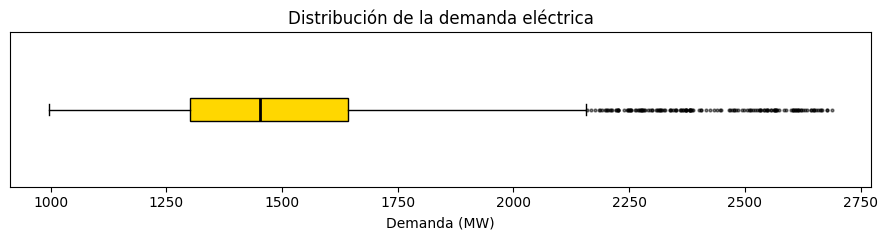

In [47]:
# Boxplot Demanda
plt.figure(figsize=(9, 2.5))
plt.boxplot(
    df["demanda"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="gold", color="black"),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markerfacecolor="black", markersize=2, alpha=0.5)
)

plt.title("Distribución de la demanda eléctrica")
plt.xlabel("Demanda (MW)")
plt.yticks([])
plt.tight_layout()
plt.show()

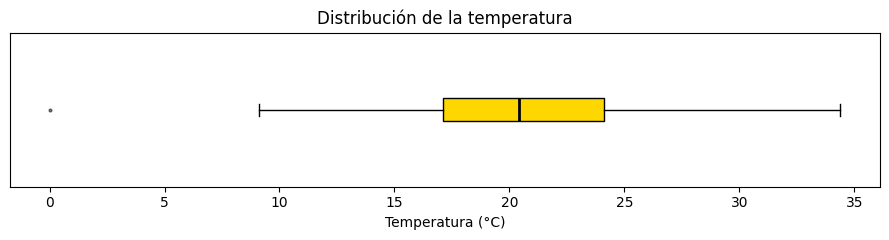

In [48]:
# Boxplot Temperatura
plt.figure(figsize=(9, 2.5))
plt.boxplot(
    df["temperatura"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="gold", color="black"),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markerfacecolor="black", markersize=2, alpha=0.5)
)

plt.title("Distribución de la temperatura")
plt.xlabel("Temperatura (°C)")
plt.yticks([])
plt.tight_layout()
plt.show()

La distribución de la demanda eléctrica presenta una forma aproximadamente normal, con ligera asimetría hacia valores altos, lo que es coherente con picos de consumo diurno en días más cálidos.

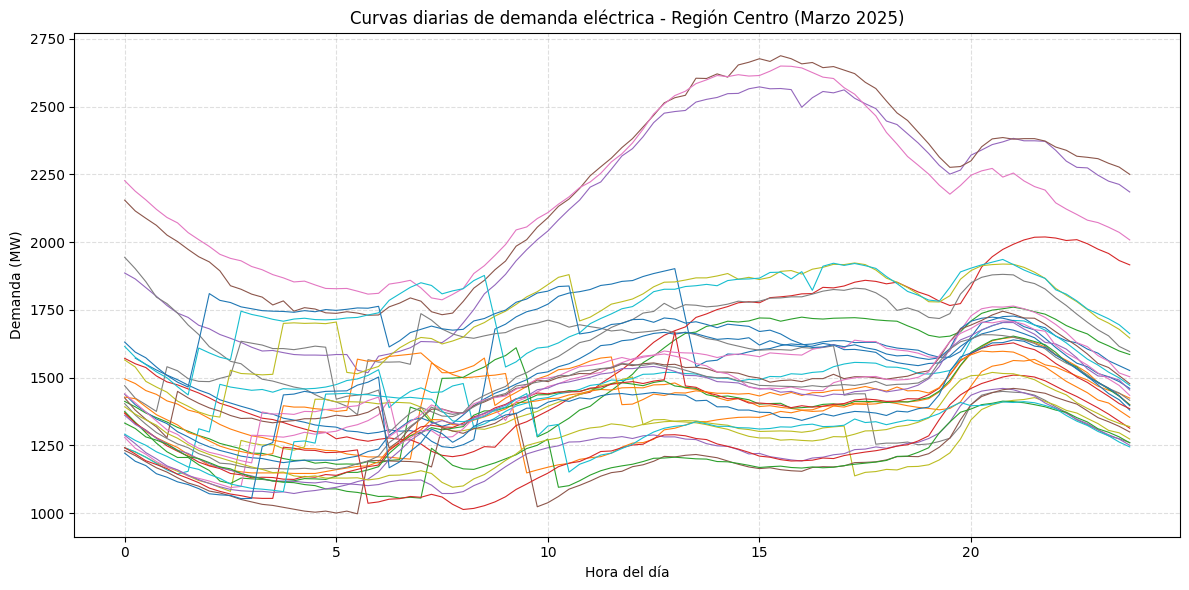

In [49]:
df["hora_decimal"] = df["datetime"].dt.hour + df["datetime"].dt.minute / 60

plt.figure(figsize=(12,6))

# Graficar una curva por día
for fecha, grupo in df.groupby("fecha"):
    plt.plot(grupo["hora_decimal"], grupo["demanda"], linewidth=0.8)

plt.title("Curvas diarias de demanda eléctrica - Región Centro (Marzo 2025)")
plt.xlabel("Hora del día")
plt.ylabel("Demanda (MW)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

A partir de los cuantiles (Q1 y Q3) y del rango intercuartílico (IQR), es posible identificar los días que presentan valores de demanda fuera del rango esperado:

In [50]:
Q1 = df["demanda"].quantile(0.25)
Q3 = df["demanda"].quantile(0.75)
IQR = Q3 - Q1

# Límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers = df[(df["demanda"] < limite_inferior) | (df["demanda"] > limite_superior)]


In [51]:
outliers["fecha"].unique()

array([datetime.date(2025, 3, 5), datetime.date(2025, 3, 6),
       datetime.date(2025, 3, 7)], dtype=object)

Se identificaron como atípicos los días 5, 6 y 7 de marzo por presentar demandas notablemente superiores al resto del mes. Por simplicidad y para evitar que dominen la estimación de la distribución, se optó por excluirlos del análisis.

In [52]:
df = df.drop(df[(df["dia"] == 5) | (df["dia"] == 6) | (df["dia"] == 7 )].index)

df["dia"].unique()

array([ 1,  2,  3,  4,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
       21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], dtype=int32)

In [53]:
# Guardado del CSV ya limpio
df.to_csv("cammesa_demanda_temp_region_centro_2025_limpio.csv", index=False, encoding="utf-8")

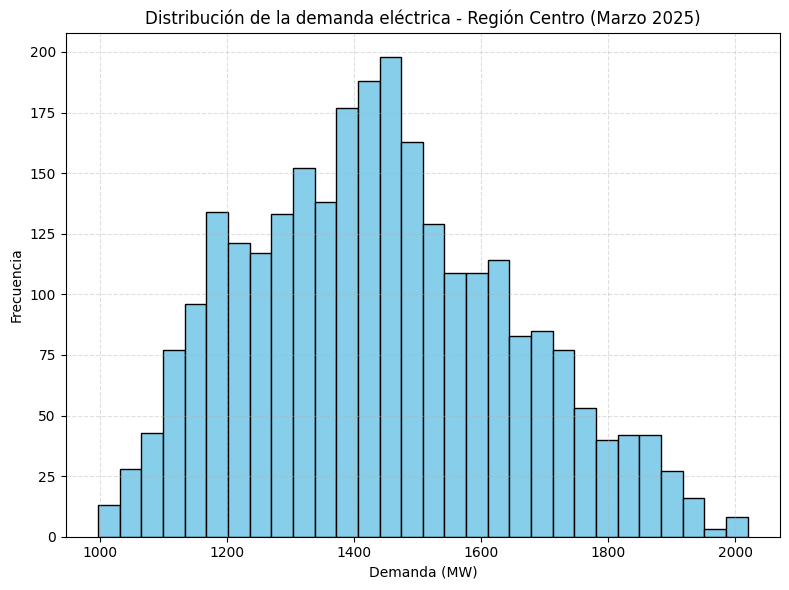

In [54]:
# Histograma DÍA COMPLETO
plt.figure(figsize=(8, 6))
plt.hist(df["demanda"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribución de la demanda eléctrica - Región Centro (Marzo 2025)")
plt.xlabel("Demanda (MW)")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Limitaremos el análisis al rango horario de 08:00 a 18:00 hs, al que llamaremos horario diurno.
El análisis se limitó al horario diurno porque en ese período la demanda eléctrica presenta un comportamiento más estable y directamente influenciado por la temperatura ambiente. En cambio, durante la noche intervienen otros factores (descenso de temperatura, menor actividad, necesidad de iluminación, etc.) que podrían distorsionar la relación entre demanda y temperatura.

In [55]:
df_diurno = df[(df['hora_decimal'] >= 8.0) & (df['hora_decimal'] <= 18.0)]

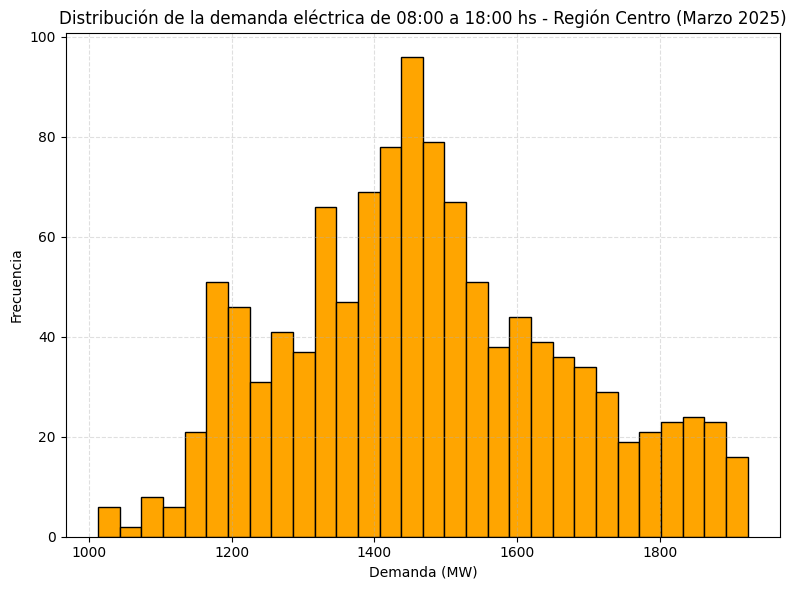

In [56]:
# Histograma demanda 08:00 a 18:00 hs
plt.figure(figsize=(8, 6))
plt.hist(df_diurno["demanda"], bins=30, color="orange", edgecolor="black")
plt.title("Distribución de la demanda eléctrica de 08:00 a 18:00 hs - Región Centro (Marzo 2025)")
plt.xlabel("Demanda (MW)")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

El comportamiento de la demanda eléctrica se muestra con una leve asimetría positiva.
Procederemos a hallar la distribución teórica que mejor se ajusta a nuestros datos:

### a) Distribución Normal

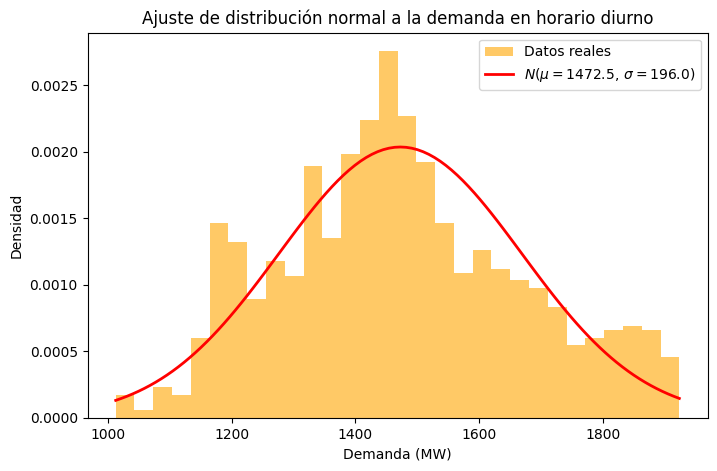

In [57]:
# Ajuste normal a demanda eléctrica HORARIO DIURNO
mu, std = st.norm.fit(df_diurno["demanda"])

xmin, xmax = df_diurno["demanda"].min(), df_diurno["demanda"].max()
x = np.linspace(xmin, xmax, 100)
p = st.norm.pdf(x, mu, std)

plt.figure(figsize=(8,5))
plt.hist(df_diurno["demanda"], bins=30, density=True, alpha=0.6, color='orange', label="Datos reales")
plt.plot(x, p, 'r', linewidth=2,
         label=fr"$N(\mu={mu:.1f},\, \sigma={std:.1f})$")

plt.title("Ajuste de distribución normal a la demanda en horario diurno")
plt.xlabel("Demanda (MW)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Verificamos con pruebas estadísticas la adecuación de la distribución propuesta:

In [58]:
# Prueba de Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(df_diurno["demanda"])
print(f"Shapiro-Wilk: estadístico = {stat_shapiro:.4f}, p = {p_shapiro:.4f}")
if p_shapiro > 0.05:
    print("Shapiro-Wilk: los datos podrían seguir una distribución normal.")
else:
    print("Shapiro-Wilk: los datos no siguen una distribución normal.")

# Prueba de Kolmogorov-Smirnov (contra normal teórica)
media = df_diurno["demanda"].mean()
desvio = df_diurno["demanda"].std()
stat_ks, p_ks = kstest(df_diurno["demanda"], 'norm', args=(media, desvio))
print(f"Kolmogorov-Smirnov: estadístico = {stat_ks:.4f}, p = {p_ks:.4f}")
if p_ks > 0.05:
    print("Kolmogorov-Smirnov: los datos podrían seguir una distribución normal.")
else:
    print("Kolmogorov-Smirnov: los datos no siguen una distribución normal.")

Shapiro-Wilk: estadístico = 0.9837, p = 0.0000
Shapiro-Wilk: los datos no siguen una distribución normal.
Kolmogorov-Smirnov: estadístico = 0.0530, p = 0.0031
Kolmogorov-Smirnov: los datos no siguen una distribución normal.


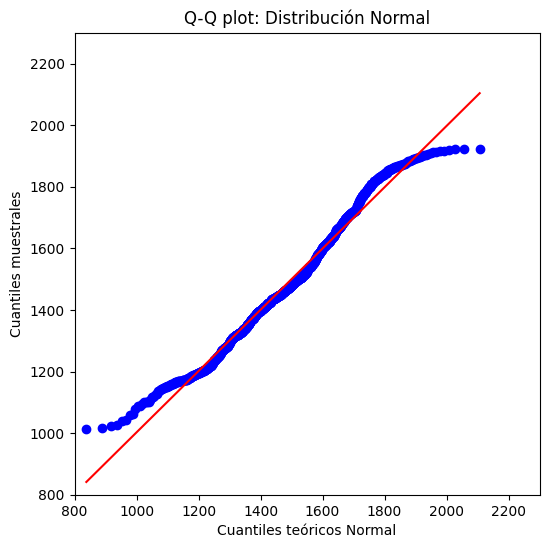

In [59]:
# QQ plot - Distribución Normal
plt.figure(figsize=(6,6))
st.probplot(df_diurno["demanda"], dist="norm", sparams=(mu, std), plot=plt)
plt.xlim(800, 2300)
plt.ylim(800, 2300)
plt.title("Q-Q plot: Distribución Normal")
plt.xlabel("Cuantiles teóricos Normal")
plt.ylabel("Cuantiles muestrales")
plt.show()

Si bien la distribucón normal podría ser una primera opción de ajuste a los datos teóricos, las pruebas estadísticas aplicadas indican que no sería la adecuada para modelar los datos.

### b) Distribución LogNormal

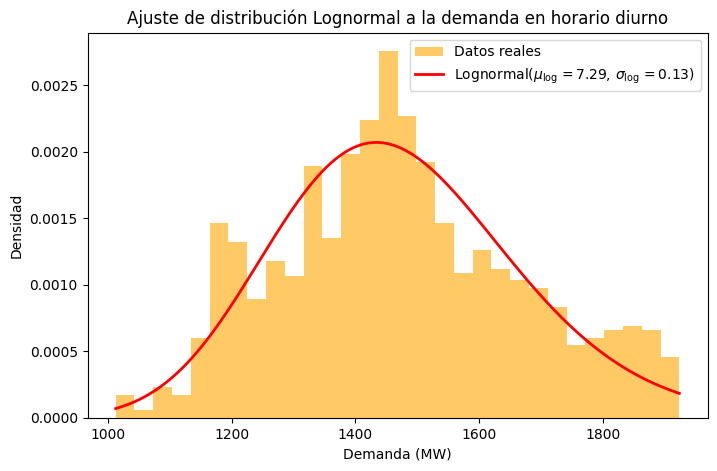

In [60]:
# Ajuste LogNormal a demanda eléctrica HORARIO DIURNO
shape, loc, scale = lognorm.fit(df_diurno["demanda"], floc=0)

xmin, xmax = df_diurno["demanda"].min(), df_diurno["demanda"].max()
x = np.linspace(xmin, xmax, 1000)

# PDF de la Lognormal ajustada
p = st.lognorm.pdf(x, s=shape, loc=loc, scale=scale)

mu_log = np.log(scale)
sigma_log = shape

plt.figure(figsize=(8,5))
plt.hist(df_diurno["demanda"], bins=30, density=True, alpha=0.6,
         color='orange', label="Datos reales")

plt.plot(x, p, 'r', linewidth=2,
         label=fr"Lognormal$(\mu_{{\log}}={mu_log:.2f},\, \sigma_{{\log}}={sigma_log:.2f})$")

plt.title("Ajuste de distribución Lognormal a la demanda en horario diurno")
plt.xlabel("Demanda (MW)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [61]:
# Parámetros lognormales (escala log)
mu_log = np.log(scale)
sigma_log = shape

# Momentos teóricos de la lognormal en escala original
mean_theoretical = np.exp(mu_log + sigma_log**2 / 2)
variance_theoretical = (np.exp(sigma_log**2) - 1) * np.exp(2*mu_log + sigma_log**2)

print("Parámetros de la distribución Lognormal ajustada:")
print(f"mu_log     (media del log):     {mu_log:.2f}")
print(f"sigma_log  (desvío del log):    {sigma_log:.2f}")
print(f"loc                         :    {loc:.2f}")
print(f"scale = exp(mu_log)         :    {scale:.2f}")

print("\nMomentos teóricos (escala original - MW):")
print(f"Media teórica:               {mean_theoretical:.2f} MW")
print(f"Desvío estándar teórico:     {np.sqrt(variance_theoretical):.2f} MW")

mean_theoretical = np.exp(mu_log + 0.5 * sigma_log**2)
var_theoretical = (np.exp(sigma_log**2) - 1) * np.exp(2*mu_log + sigma_log**2)
std_theoretical = np.sqrt(var_theoretical)

Parámetros de la distribución Lognormal ajustada:
mu_log     (media del log):     7.29
sigma_log  (desvío del log):    0.13
loc                         :    0.00
scale = exp(mu_log)         :    1459.55

Momentos teóricos (escala original - MW):
Media teórica:               1472.56 MW
Desvío estándar teórico:     197.06 MW


Verificamos con prueba estadística de Kolmogorov-Smirnov la adecuación de la distribución LogNormal propuesta:

In [62]:
# Prueba de Kolmogorov-Smirnov (contra Lognormal teórica)
stat_ks, p_ks = kstest(df_diurno["demanda"], 'lognorm', args=(shape, loc, scale))
print(f"Kolmogorov-Smirnov: estadístico = {stat_ks:.4f}, p = {p_ks:.4f}")
if p_ks > 0.05:
    print("Kolmogorov-Smirnov: los datos podrían seguir una distribución lognormal.")
else:
    print("Kolmogorov-Smirnov: los datos no siguen una distribución lognormal.")

Kolmogorov-Smirnov: estadístico = 0.0300, p = 0.2475
Kolmogorov-Smirnov: los datos podrían seguir una distribución lognormal.


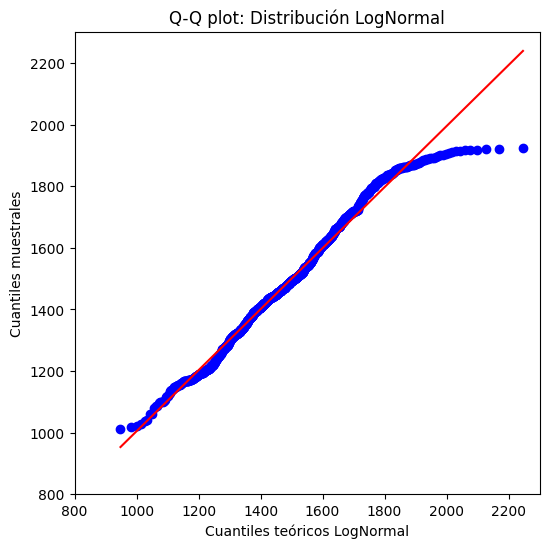

In [63]:
# QQ plot - Distribución LogNormal
plt.figure(figsize=(6,6))
st.probplot(df_diurno["demanda"], dist="lognorm", sparams=(shape, loc, scale), plot=plt)
plt.xlim(800, 2300)
plt.ylim(800, 2300)
plt.title("Q-Q plot: Distribución LogNormal")
plt.xlabel("Cuantiles teóricos LogNormal")
plt.ylabel("Cuantiles muestrales")
plt.show()

Vemos que la distribución LogNormal propuesta presentan un mejor ajuste que la distribución Normal antes planteada. La prueba de KS indica que los datos podrían provenir de la distribución LogNormal teórica y también vemos en el gráfico QQ plot un mejor ajuste de los puntos sobre la diagonal.

### Gráfico de Distribución Normal vs. LogNormal

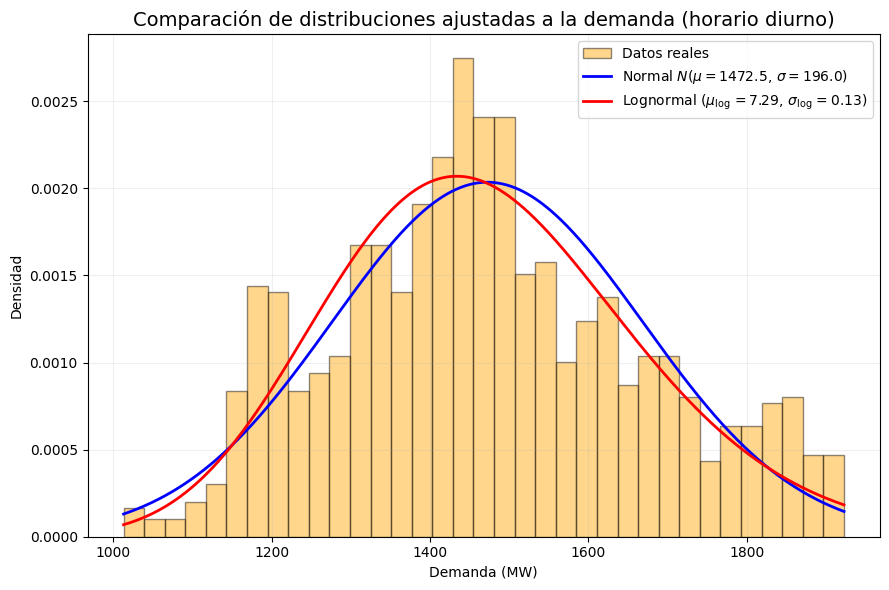

In [64]:
x_data = df_diurno["demanda"]

# Ajuste Normal
mu, std = st.norm.fit(x_data)

# Ajuste LogNormal
shape, loc, scale = lognorm.fit(x_data, floc=0)
mu_log = np.log(scale)
sigma_log = shape

xmin, xmax = x_data.min(), x_data.max()
x = np.linspace(xmin, xmax, 1000)

# PDFs
pdf_normal = st.norm.pdf(x, mu, std)
pdf_lognorm = st.lognorm.pdf(x, s=shape, loc=loc, scale=scale)

# Gráfico
plt.figure(figsize=(9,6))

# Histograma (datos reales)
plt.hist(x_data, bins=35, density=True, alpha=0.45,
         color="orange", edgecolor="black", label="Datos reales")

# Curva Normal
plt.plot(x, pdf_normal, "b-", linewidth=2,
         label=fr"Normal $N(\mu={mu:.1f},\, \sigma={std:.1f})$")

# Curva Lognormal
plt.plot(x, pdf_lognorm, "r-", linewidth=2,
         label=fr"Lognormal $(\mu_{{\log}}={mu_log:.2f},\, \sigma_{{\log}}={sigma_log:.2f})$")

plt.title("Comparación de distribuciones ajustadas a la demanda (horario diurno)", fontsize=14)
plt.xlabel("Demanda (MW)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Simulaciones

### 4.1 Simulación de demanda eléctrica en horario diurno (escenario base)

Simularemos una gran cantidad de posibles valores de demanda (n=10.000) a partir de la distribución lognormal ajustada a los datos observados.
Esto permite estimar la variabilidad esperada del sistema bajo condiciones similares al escenario real.

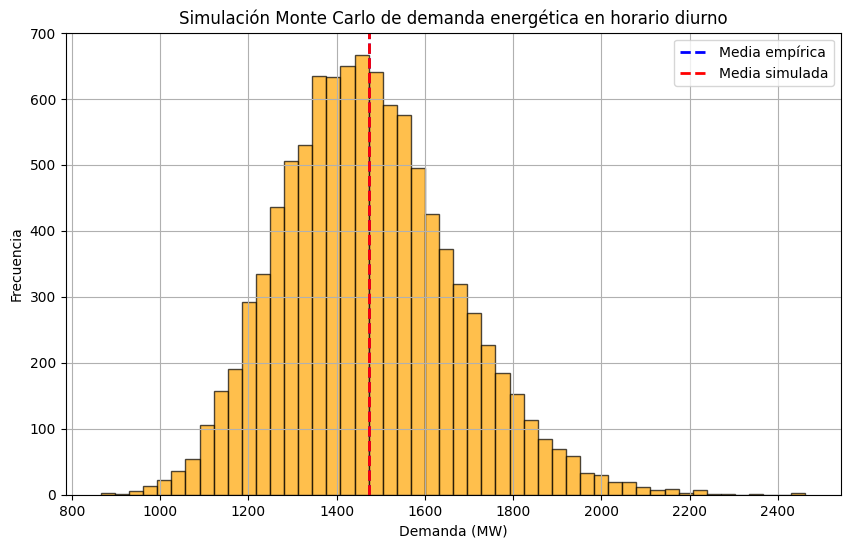

In [65]:
# Fijar semilla para reproducibilidad
np.random.seed(42)

# Datos de distribución de demanda en horario diurno
media_demanda = df_diurno['demanda'].mean()

# Simulación de 10.000 escenarios
demanda_simulada = np.random.lognormal(mean=mu_log, sigma=sigma_log, size=10000)

# Visualización
plt.figure(figsize=(10,6))
plt.hist(demanda_simulada, bins=50, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(media_demanda, color='blue', linestyle='dashed', linewidth=2, label='Media empírica')
plt.axvline(demanda_simulada.mean(), color='red', linestyle='dashed', linewidth=2, label='Media simulada')
plt.title('Simulación Monte Carlo de demanda energética en horario diurno')
plt.xlabel('Demanda (MW)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
# Estadísticos de la simulación general

media_sim = np.mean(demanda_simulada)
std_sim = np.std(demanda_simulada, ddof=1)

print("SIMULACIÓN GENERAL – Demanda diurna:")
print(f"Media simulada: {media_sim:.2f} MW")
print(f"Desvío estándar: {std_sim:.2f} MW")

SIMULACIÓN GENERAL – Demanda diurna:
Media simulada: 1472.24 MW
Desvío estándar: 197.75 MW


### 4.2 Simulación de demanda eléctrica en horario diurno según tipo de día

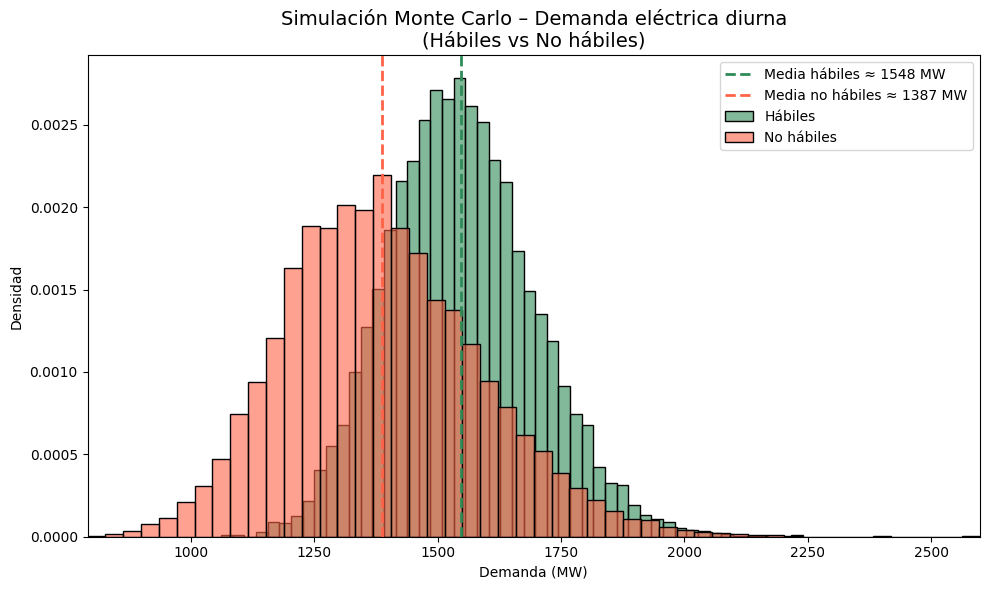

In [67]:
# HÁBILES
datos_h = df_diurno.loc[df_diurno['tipo_dia'] == 'Hábil', 'demanda']
shape_h, loc_h, scale_h = st.lognorm.fit(datos_h, floc=0)
mu_log_h = np.log(scale_h)
sigma_log_h = shape_h

# NO HÁBILES
datos_nh = df_diurno.loc[df_diurno['tipo_dia'] == 'No hábil', 'demanda']
shape_nh, loc_nh, scale_nh = st.lognorm.fit(datos_nh, floc=0)
mu_log_nh = np.log(scale_nh)
sigma_log_nh = shape_nh

# Simulación Monte Carlo

n = 10_000
np.random.seed(42)

demanda_h_sim = np.random.lognormal(mean=mu_log_h, sigma=sigma_log_h, size=n)
demanda_nh_sim = np.random.lognormal(mean=mu_log_nh, sigma=sigma_log_nh, size=n)

# Medias

media_h = demanda_h_sim.mean()
media_nh = demanda_nh_sim.mean()

# Histograma

plt.figure(figsize=(10, 6))
plt.title("Simulación Monte Carlo – Demanda eléctrica diurna\n(Hábiles vs No hábiles)", fontsize=14)

# Rango común de bins
xmin = min(demanda_h_sim.min(), demanda_nh_sim.min())
xmax = max(demanda_h_sim.max(), demanda_nh_sim.max())

sns.histplot(
    demanda_h_sim,
    bins=50,
    stat="density",
    color="seagreen",
    label="Hábiles",
    alpha=0.6
)

sns.histplot(
    demanda_nh_sim,
    bins=50,
    stat="density",
    color="tomato",
    label="No hábiles",
    alpha=0.6
)

# Líneas de media simulada
plt.axvline(media_h, color="seagreen", linestyle="--", linewidth=2,
            label=f"Media hábiles ≈ {media_h:.0f} MW")
plt.axvline(media_nh, color="tomato", linestyle="--", linewidth=2,
            label=f"Media no hábiles ≈ {media_nh:.0f} MW")

plt.xlabel("Demanda (MW)")
plt.ylabel("Densidad")
plt.xlim(xmin, xmax)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# Cálculos para días hábiles
media_h = np.mean(demanda_h_sim)
std_h = np.std(demanda_h_sim, ddof=1)

print("HÁBILES:")
print(f"Media simulada: {media_h:.2f} MW")
print(f"Desvío estándar: {std_h:.2f} MW")
print(f"-------------------------------")
# Cálculos para días no hábiles
media_nh = np.mean(demanda_nh_sim)
std_nh = np.std(demanda_nh_sim, ddof=1)

print("NO HÁBILES:")
print(f"Media simulada: {media_nh:.2f} MW")
print(f"Desvío estándar: {std_nh:.2f} MW")

HÁBILES:
Media simulada: 1547.95 MW
Desvío estándar: 148.22 MW
-------------------------------
NO HÁBILES:
Media simulada: 1387.45 MW
Desvío estándar: 199.40 MW


En promedio, los días hábiles presentan una demanda diurna mayor que los días no hábiles, con medias simuladas de aproximadamente 1547 MW vs 1387 MW, respectivamente. Los días hábiles tienden a mostrar mayor demanda promedio diurna, debido al funcionamiento simultáneo de la actividad comercial, industrial y de oficinas.
En los días no hábiles, la demanda disminuye.

### 4.3 Relación entre demanda eléctrica y temperatura

Analizaremos cómo varia la demanda eléctrica en relacion con la temperatura solamente para el rango horario de 08:00 a 18:00 hs.

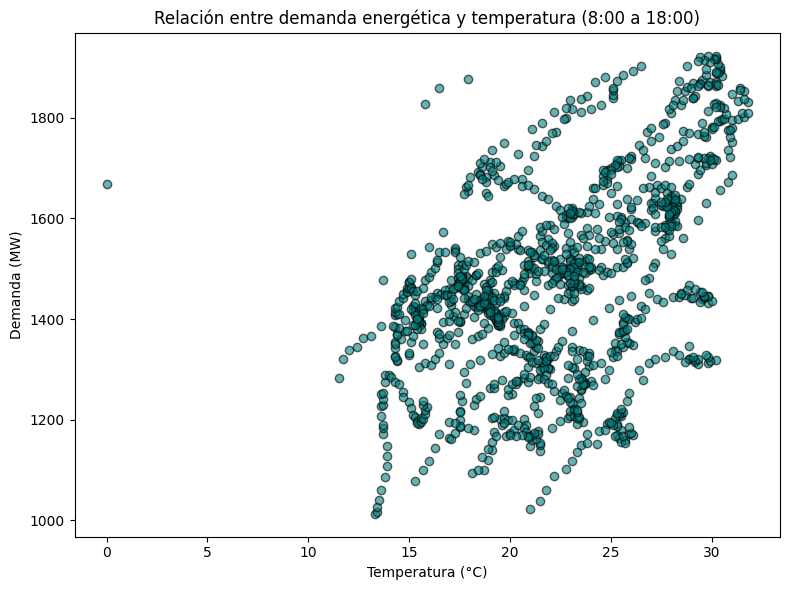

In [69]:
# Gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(df_diurno['temperatura'], df_diurno['demanda'], alpha=0.6, color='teal', edgecolor='black')
plt.title('Relación entre demanda energética y temperatura (8:00 a 18:00)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Demanda (MW)')
plt.tight_layout()
plt.show()

Observamos la presencia de un registro con temperatura igual a 0°. Teniendo en cuenta que el periodo analizado es un mes con temperatura más altas y que se trata de un único registro, lo eliminaremos por considerarlo un valor atípico.

In [70]:
# Eliminación de registro 0° C
df_diurno = df_diurno[df_diurno["temperatura"] != 0]

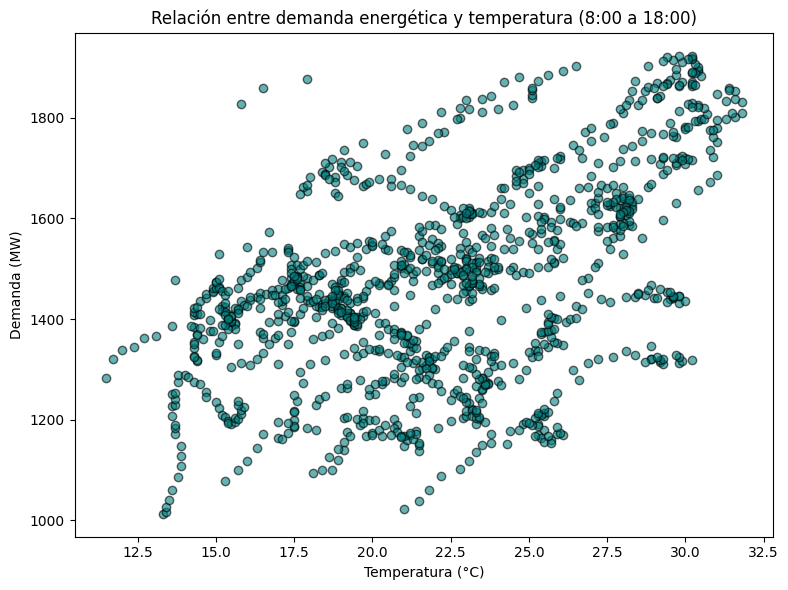

In [71]:
# Gráfico de dispersión
plt.figure(figsize=(8, 6))
plt.scatter(df_diurno['temperatura'], df_diurno['demanda'], alpha=0.6, color='teal', edgecolor='black')
plt.title('Relación entre demanda energética y temperatura (8:00 a 18:00)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Demanda (MW)')
plt.tight_layout()
plt.show()

In [72]:
corr_pearson = st.pearsonr(df_diurno['demanda'], df_diurno['temperatura'])
corr_pearson

PearsonRResult(statistic=np.float64(0.5123894576475336), pvalue=np.float64(8.730960000728685e-78))

Asumiremos una relación lineal entre demanda eléctrica y temperatura. A continuación, hallaremos la ecuación que la describe:

In [73]:
from sklearn.linear_model import LinearRegression

# Variables
X_temp = df_diurno[['temperatura']]
y_demanda = df_diurno['demanda']

# Ajuste del modelo lineal
modelo_temp = LinearRegression().fit(X_temp, y_demanda)
pendiente = modelo_temp.coef_[0]
intercepto = modelo_temp.intercept_

print(f"La ecuación que describe la relación es: demanda eléctrica (MW) = {pendiente:.2f} (MW/°C) * temperatura (°C) + {intercepto:.2f} MW")

La ecuación que describe la relación es: demanda eléctrica (MW) = 21.51 (MW/°C) * temperatura (°C) + 993.81 MW


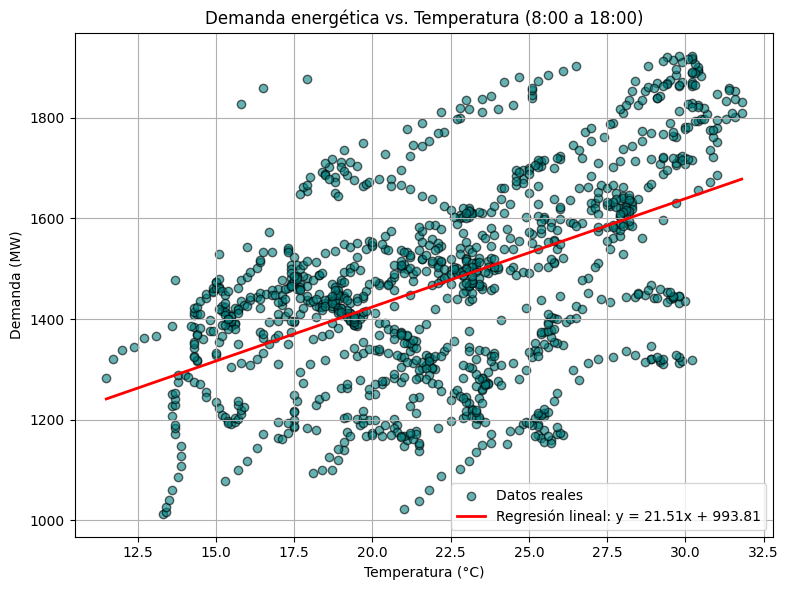

In [74]:
# Predicción para la línea de tendencia
temp_range = np.linspace(X_temp.min(), X_temp.max(), 100)
temp_range_df = pd.DataFrame(temp_range, columns=['temperatura'])
demanda_pred = modelo_temp.predict(temp_range_df)

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(X_temp, y_demanda, alpha=0.6, color='teal', edgecolor='black', label='Datos reales')
plt.plot(temp_range, demanda_pred, color='red', linewidth=2,
         label=f'Regresión lineal: y = {pendiente:.2f}x + {intercepto:.2f}')
plt.title('Demanda energética vs. Temperatura (8:00 a 18:00)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Demanda (MW)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Simulación de demanda eléctrica ante aumento de temperatura en +2 °C

Se aplicó la ecuación del modelo lineal (demanda = intercepto + pendiente*temperatura) para ajustar los valores reales de demanda eléctrica ante un escenario hipotético de +2 °C.
Luego, mediante 10000 simulaciones Monte Carlo, se generaron posibles valores de la demanda diaria, incorporando variaciones aleatorias con la misma dispersión que los residuos del modelo.
De este modo se obtuvieron las distribuciones simuladas para los escenarios "base" y "+2 °C", permitiendo analizar cómo podría cambiar la demanda promedio diaria ante un aumento de temperatura.

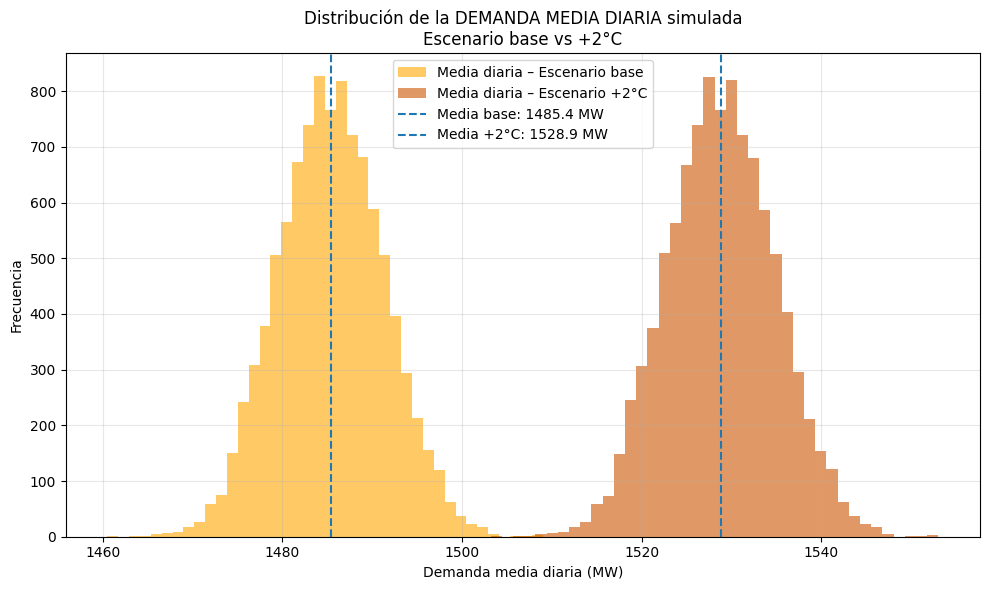

In [75]:
# Configuración Monte Carlo
n_sim = 10_000
np.random.seed(42)

media_base = np.zeros(n_sim)
media_plus2 = np.zeros(n_sim)

delta_demanda = pendiente * 2     # desplazamiento por +2°C
demanda_real = df_diurno["demanda"].values

for i in range(n_sim):

    # Ruido LOGNORMAL
    ruido = np.random.lognormal(mean=0, sigma=sigma_log, size=len(demanda_real))

    # Escenario base: demanda * ruido
    demanda_base_sim = demanda_real * ruido

    # Escenario +2°C: desplazada por lineal + ruido
    demanda_plus2_sim = (demanda_real + delta_demanda) * ruido

    # Guardamos la media diaria simulada
    media_base[i] = demanda_base_sim.mean()
    media_plus2[i] = demanda_plus2_sim.mean()

# Gráfico
plt.figure(figsize=(10, 6))
plt.hist(media_base, bins=40, alpha=0.6, density=False,
         label='Media diaria – Escenario base', color='orange')
plt.hist(media_plus2, bins=40, alpha=0.6, density=False,
         label='Media diaria – Escenario +2°C', color='#CC5500')

plt.axvline(media_base.mean(), linestyle='--', label=f"Media base: {media_base.mean():.1f} MW")
plt.axvline(media_plus2.mean(), linestyle='--', label=f"Media +2°C: {media_plus2.mean():.1f} MW")

plt.xlabel('Demanda media diaria (MW)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la DEMANDA MEDIA DIARIA simulada\nEscenario base vs +2°C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
# Resultados numéricos resumidos
inc_esperado = media_plus2.mean() - media_base.mean()

# Intervalos de confianza al 95%
ic_base = np.percentile(media_base, [2.5, 97.5])
ic_plus2 = np.percentile(media_plus2, [2.5, 97.5])

print(f"Media simulada BASE : {media_base.mean():.1f} MW "
      f"(IC95% {ic_base[0]:.1f} – {ic_base[1]:.1f})")

print(f"Media simulada +2°C: {media_plus2.mean():.1f} MW "
      f"(IC95% {ic_plus2[0]:.1f} – {ic_plus2[1]:.1f})")

print(f"Incremento esperado por +2°C: {inc_esperado:.1f} MW")

Media simulada BASE : 1485.4 MW (IC95% 1474.4 – 1497.0)
Media simulada +2°C: 1528.9 MW (IC95% 1517.5 – 1540.8)
Incremento esperado por +2°C: 43.4 MW
